In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("Crime_Data_from_2020_to_Present.csv")
df.head(300)
df = df.sample(10000)

In [2]:
df.shape

(10000, 28)

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print("everything imported")
# =====================================================
# 1. CLEANING
# =====================================================

print("about to drop duplicates")
# Remove duplicates
df = df.drop_duplicates()
print("duplicates done")

# Filter unrealistic victim ages
df = df[(df['Vict Age'] >= 0) & (df['Vict Age'] <= 100)]

# Fill missing values
df['Vict Sex'] = df['Vict Sex'].fillna("X")
df['Vict Descent'] = df['Vict Descent'].fillna("X")

# Convert TIME OCC into hour
df['TIME OCC'] = df['TIME OCC'].apply(lambda x: int(str(x).zfill(4)[:2]))

# Drop rows missing the target
df = df.dropna(subset=['Crm Cd Desc'])


# =====================================================
# 2. REMOVE RARE CRIME TYPES
# =====================================================
crime_counts = df['Crm Cd Desc'].value_counts()
rare_classes = crime_counts[crime_counts < 20].index  

print("about to check for rare classes")
# remove rows where target is rare
df = df[~df['Crm Cd Desc'].isin(rare_classes)]
# =====================================================
# 3. SELECT FEATURES + TARGET
# =====================================================
features = ['AREA NAME', 'Premis Desc', 'Vict Age', 'Vict Sex', 'TIME OCC']
label = 'Crm Cd Desc'

X = df[features]
y = df[label]


# =====================================================
# 4. TRAIN/TEST SPLIT
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


# =====================================================
# 5. PREPROCESSING (ENCODING + SCALING)
# =====================================================
categorical_cols = ['AREA NAME', 'Premis Desc', 'Vict Sex']
numeric_cols = ['Vict Age', 'TIME OCC']

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)


# =====================================================
# 6. RANDOM FOREST MODEL
# =====================================================
rf_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(n_estimators=200, random_state=42))
])

print("About to fit to data")
rf_model.fit(X_train, y_train)
print("done")
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_test_acc = accuracy_score(y_test, rf_test_pred)


# =====================================================
# 7. PRINT ACCURACY
# =====================================================
print("\n=== Random Forest ===")
print("Training Accuracy:", round(rf_train_acc, 4))
print("Test Accuracy:", round(rf_test_acc, 4))

everything imported
about to drop duplicates
duplicates done
about to check for rare classes
About to fit to data
done

=== Random Forest ===
Training Accuracy: 0.8382
Test Accuracy: 0.2778


about to do plot 1


C:\Users\roopa\AppData\Local\Temp\ipykernel_22644\4091333969.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


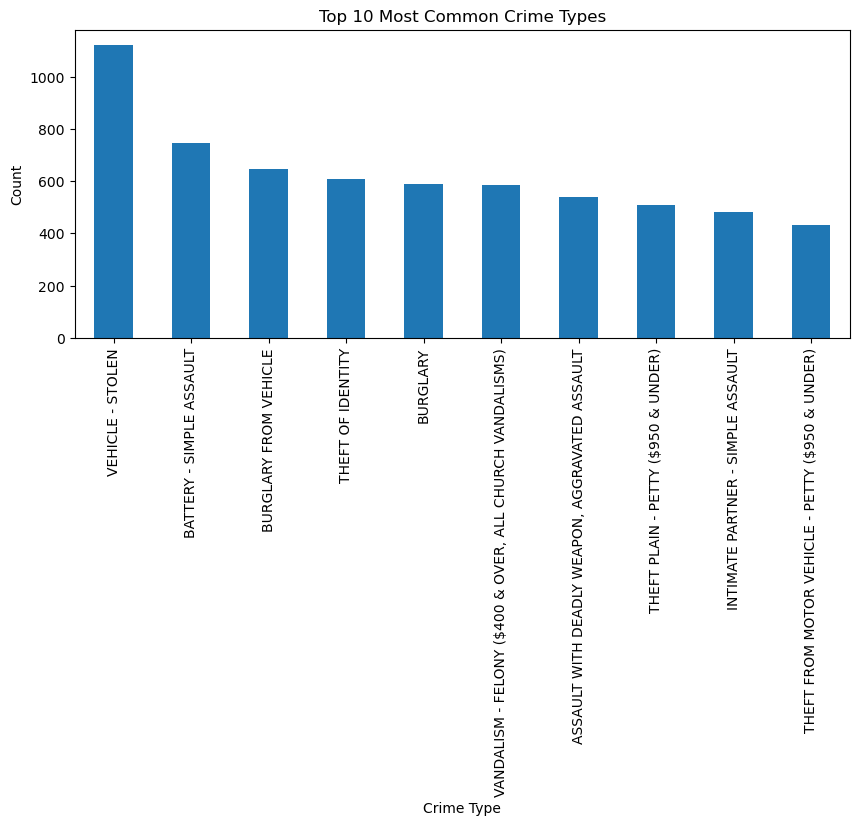

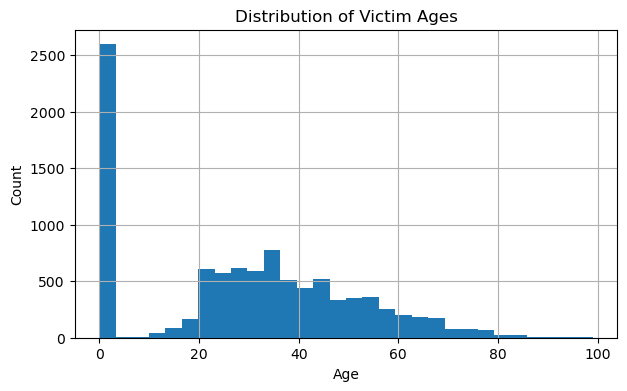

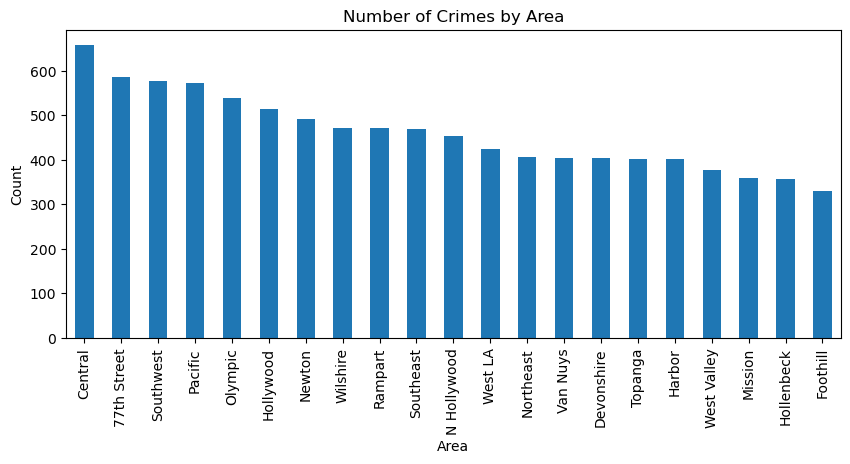

In [6]:
# =====================================================
# 9. REQUIRED VISUALIZATIONS
# =====================================================
print("about to do plot 1")
# ---- Visualization 1: Crime Type Distribution ----
plt.figure(figsize=(10,4))
df['Crm Cd Desc'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Most Common Crime Types")
plt.xlabel("Crime Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()
print("Most crimes fall into just a few categories. “Vehicle–Stolen” is the biggest one, and the rest are mostly property crimes.)

# ---- Visualization 2: Victim Age Distribution ----
plt.figure(figsize=(7,4))
df['Vict Age'].hist(bins=30)
plt.title("Distribution of Victim Ages")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()
print("A lot of ages were missing, but most real ages fall between 20–40. Very young and very old ages appear less often.")

# ---- Visualization 3: Crimes by Area ----
plt.figure(figsize=(10,4))
df['AREA NAME'].value_counts().plot(kind='bar')
plt.title("Number of Crimes by Area")
plt.xlabel("Area")
plt.ylabel("Count")
plt.show()
print("Crime isn’t spread evenly. A few areas (like Central and 77th Street) have way more crimes than others.")